# 1 Introduction

In this week's exercise session we will learn how to use Machine Learning methods to solve regression problems. In particular, we will focus on linear regression. 

First let us import the libraries we will be using during this exercise:

In [1]:
# Useful starting lines
%matplotlib inline
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

# 2 The regression problem

We have seen in class that regression refers to predicting continous values for a given sample. A nice example could be predicting the first salary of a student after graduation given how diligent they were with attending machine learning exercise sessions. We were introduced to the "linear regression method". 

**Q: How does a regression problem differ from a classification problem?**
- A classification problem has discrete-valued target variables, whereas the values of target variables in regression problems may be continuous.
- The target variables in a regression problem can be ordered (e.g., by increasing value).

**Q: Why is the linear regression model a linear model?**
- The output of the linear regression model is a linear function of the inputs.

# 2.1 Load and inspect the data

This week, using linear regression, we will analyze the California Housing dataset and predict median house values from neighborhood-level features such as median income, average number of rooms, population, and location-related variables.

We load the dataset and split it into training and test sets, using 80% of the data for training and 20% for testing.

In [ ]:
# get the data set and print a description
from sklearn.datasets import fetch_california_housing

housing_dataset = fetch_california_housing()          
print(housing_dataset.DESCR)


.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
X = housing_dataset["data"]
y = housing_dataset["target"]

# remove samples where the target is capped at 5.0 to reduce the ceiling effect
mask = y < 5.0
X = X[mask]
y = y[mask]



print("Shape of the data sample matrix X:", X.shape)

N = X.shape[0]
D = X.shape[1]
print("The number of data samples is N:", N)
print("The number of features is D:", D)

print("\nShape of the labels vector y:", y.shape)

print("\nFirst data sample in X:", X[0,:])
print("First label in y:", y[0])



Shape of the data sample matrix X: (19648, 8)
The number of data samples is N: 19648
The number of features is D: 8

Shape of the labels vector y: (19648,)

First data sample in X: [   8.3252       41.            6.98412698    1.02380952  322.
    2.55555556   37.88       -122.23      ]
First label in y: 4.526


Our first exercise is to split the data into training and test sets. Let's set aside 80% of the data for training and 20% for testing. 

Your steps should be the following ones:
1. Generate a vector of indices from 0 to N-1 (with N being the number of data samples) (Hint: you can use the function np.arange()
2. Shuffle the indices (hint: you can use np.random.shuffle(). Look up how to use this function!)
3. Select 80% of the indices. We have coded this for you but make sure you understand what these lines are doing!

In [4]:
split_ratio = 0.8

N = X.shape[0]  

indices = np.arange(N)

np.random.seed(0)     

np.random.shuffle(indices)

X_train = X[indices[:int(N*split_ratio)], :]

y_train = y[indices[:int(N*split_ratio)]]

X_test  = X[indices[int(N*split_ratio):], :]

y_test  = y[indices[int(N*split_ratio):]]

Check the shapes of `X_train`, `y_train`, `X_test`, `y_test`

In [5]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(15718, 8)
(15718,)
(3930, 8)
(3930,)


After, we normalize the data such that each feature has zero mean and unit standard deviation. (Since you have not seen this in the lectures yet, we have provided the code for you. Study this well, we will be doing a lot of normalization during the exercise sessions!)

In [6]:
'''
Make mean 0 and std dev 1 of the data.
'''
def normalize(X):
    mu    = np.mean(X,0,keepdims=True)
    std   = np.std(X,0,keepdims=True) 
    X     = (X-mu)/std
    return X, mu, std

#Use train stats for normalizing test set
X_train,mu_train,std_train = normalize(X_train)
X_test = (X_test-mu_train)/std_train

Correlation: 0.6507287886480051


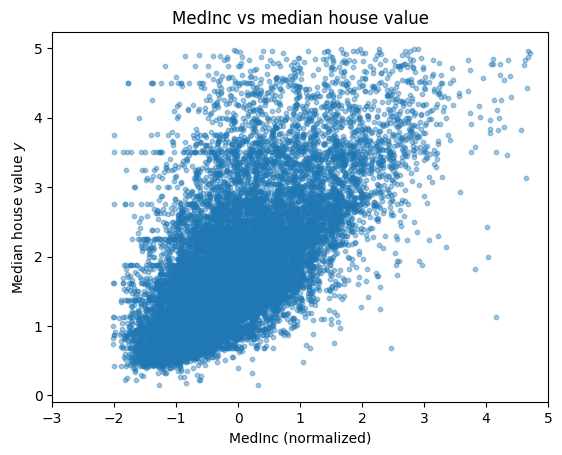

In [7]:
# Exploratory analysis: visualize the relationship between MedInc (median income) and the target (median house value).
feature = 0
plt.scatter(X_train[:, feature], y_train, s=10, alpha=0.4)

plt.xlim(-3, 5)
plt.xlabel("MedInc (normalized)")
plt.ylabel("Median house value $y$")
plt.title("MedInc vs median house value")

corr = np.corrcoef(X_train[:, feature], y_train)[0, 1]
print("Correlation:", corr)


**Q: Using the code above, explore the relation between different features and the house prices. Describe what you see. Can you identify any trends?**


- The relationships differ by feature: some features (e.g., MedInc) tend to increase with house value, while others (e.g., AveOccup) tend to decrease. Several features show weak or non-linear patterns in a simple scatter plot. The target values lie between 0 and 5 because the median house value is measured in units of $100,000 and the dataset clips values at 5.0 (i.e., $500,000).

# 2.2 Closed-form solution for linear regression


The linear regression method has a closed form, analytical solution, as we have also seen in class.

$$ \mathbf{w^*} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y} $$


Now let's code the analytical solution in the function `get_w_analytical` and to obtain the weight parameters $\mathbf{w}$. Tip: You may want to use the function np.linalg.pinv. 


In [8]:
def get_w_analytical(X_train,y_train):
    """
    compute the weight parameters w
    """
        
    # compute w via the analytical solution
    w = np.linalg.pinv(X_train)@y_train
    return w


To assess our method's performance, we'll be using the mean squared error (MSE). 

$$ MSE = \frac{1}{N}\sum_{i=1}^N (\hat{y}_i - y_i)^2$$

where our prediction $\hat{y}_i = \mathbf{x}_i^T \cdot \mathbf{w} $.



Let's code this!

In [9]:

def get_loss(w, X_train, y_train,X_test,y_test):

    loss_train = (np.mean((y_train-X_train@w)**2))
    loss_test = (np.mean((y_test-X_test@w)**2))
    print("The training loss is {}. The test loss is {}.".format(loss_train, loss_test))

    return loss_test

In [10]:
#Let's test our code!
w_ana = get_w_analytical(X_train,y_train)
get_loss(w_ana, X_train,y_train, X_test,y_test)

The training loss is 4.104190149202492. The test loss is 4.056991784214816.


np.float64(4.056991784214816)

**What is the shape of the weights $\mathbf{w}$?**
- The shape is 8, which is the number of input features.

# 2.3. Adding a bias term

The error is still relatively large! Note however that, in contrast to what we have seen in the lectures, we did not use any bias term $\text{w}^{(0)}$. Let's see whether we can reduce the error by including a bias term.

First, let's look more closely at what happens without a bias term. Formally, without a bias term, we are fitting a hyperplane that always passes through the origin. This is because our predictions can be expressed as
$$ \hat{y}_i = \text{w}^{(1)}x_i^{(1)} +  \text{w}^{(2)}x_i^{(2)} + ... + \text{w}^{(12)}x_i^{(12)} $$

or

$$ \hat{y}_i = \mathbf{x}_i^T \cdot \mathbf{w} $$

Therefore, when $\mathbf{x}_i=\mathbf{0}$, $\hat{y}_i= 0$, no matter what values $\mathbf{w}$ takes. That's not ideal!

Note: If you are confused about the transpose operation in $\hat{y}_i = \mathbf{x}_i^T \cdot \mathbf{w}$ above, here are the shapes of the matrices that are being multiplied:  
* $\mathbf{w}$ is DX1 
* $\mathbf{x}_i$ is DX1 (A reminder: The entire data $\mathbf{X}$ is NXD, but when we select a single data sample from it, we express it as a column vector!) 
* The result $\hat{y}_i$ is 1x1




**Introducing the bias term:**
        
It would be a lot nicer if our predicted hyperplane didn't always have to pass through the origin. In math words:

$$ \hat{y}_i = \text{w}^{(0)} + \text{w}^{(1)}x_i^{(1)} +  \text{w}^{(2)}x_i^{(2)} + ... + \text{w}^{(12)}x_i^{(12)} $$

Here, the $\text{w}^{(0)}$ is the y-intercept. When $\mathbf{x}_i=\mathbf{0}$, $y_i= \text{w}^{(0)}$. Neat!


To handle this, we can add a column of 1s as a feature in our data $\mathbf{X}$. This way, we could just say that the last feature $x_i^{(0)} = 1$ and

$$ \hat{y}_i = \text{w}^{(0)}\cdot 1 + \text{w}^{(1)}x_i^{(1)} +  \text{w}^{(2)}x_i^{(2)} + ... + \text{w}^{(12)}x_i^{(12)} $$

$$ \hat{y}_i = \text{w}^{(0)}x_i^{(0)} + \text{w}^{(1)}x_i^{(1)} +  \text{w}^{(2)}x_i^{(2)} + ... + \text{w}^{(12)}x_i^{(12)} $$

$$ \hat{y}_i = \mathbf{x}_i^T \cdot \mathbf{w} $$





And we can keep using the same analytical solution formula as above! So by adding a column of 1s as the last feature of $\mathbf{X}$, and running the analytical solution, we will find a $\mathbf{w}$ with 9 features instead of 8. The last feature of the weights $\mathbf{w}^{(0)}$ will be the bias term. This way, we wouldn't have to change any of the functions we wrote above.

So let's get to it! Fill in the function below to append a bias term to the data matrices $\mathbf{X}$. Your steps should be the following:
1. Create a numpy array that is a column of 1s. It's shape should be NX1.
2. Concatenate the ones column with the data matrix. Hint: use np.concatenate. Be careful what axis you specify!

In [11]:
def append_bias_term(X):

    ones_column = np.ones([X.shape[0], 1])
    X_bias = np.concatenate([X, ones_column], axis=1)
    return X_bias

In [12]:
X_train_bias = append_bias_term(X_train)
X_test_bias = append_bias_term(X_test)

w_ana = get_w_analytical(X_train_bias,y_train)

get_loss(w_ana, X_train_bias,y_train, X_test_bias,y_test)

The training loss is 0.4034401020891835. The test loss is 0.4041042139243986.


np.float64(0.4041042139243986)

Now your loss should be lower. This is much better!

# 2.5 Using sklearn


We can also use the sklearn implementation of the linear regression model. sklearn is a library that contains implementations of many popular machine learning models, including the linear regression model!

Please look up the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) to 

1. instantiate the LinearRegression model
2. fit the model to our training data
3. evaluate the model on the test data
4. and compare the results with our previous outcomes

Especially check out the example code they provide!

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

model = LinearRegression()
model.fit(X_train,y_train)
y_hat = model.predict(X_test)

print('MSE of sklearn linear regression model on test data: ' , metrics.mean_squared_error(y_test,y_hat))

MSE of sklearn linear regression model on test data:  0.40410421392439994
